In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load processed CSV
df = pd.read_csv(os.path.join("..", "data", "processed", "cardio_onc_prostate_03cleaned.csv"))
df['toxicity'] = (
    (df['bp_meds_post'] != 0) |
    (df['lipid_meds_post'] != 0) |
    (df['dm_meds_post'] != 0)
)

# Number of patients on each NHT

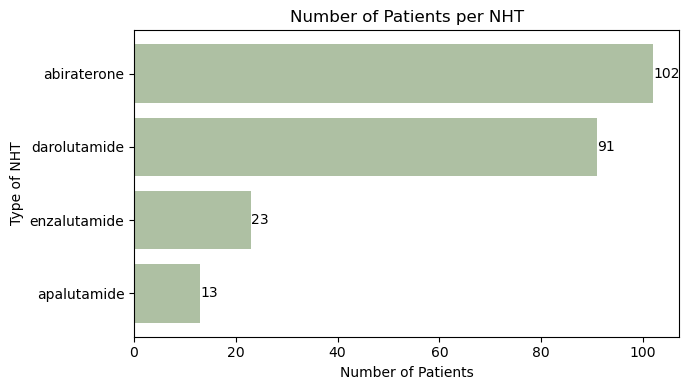

In [ ]:
# Standardize case of specific_nht_used
df['specific_nht_used'] = df['specific_nht_used'].str.lower()

# Count unique patients per NHT
num_patients = df.groupby('specific_nht_used')['unique_patient_id'].nunique()

# There are a couple spelling errors we need to correct later. Omit for now.
num_patients = num_patients[num_patients > 1]
num_patients = num_patients.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

p=ax.barh(num_patients.index, num_patients.values,
          color='#aec0a3')
ax.bar_label(p, label_type='edge')
ax.set_ylabel('Type of NHT')
ax.set_xlabel('Number of Patients')
ax.set_title('Number of Patients per NHT')
plt.tight_layout()
plt.show()

# Additional ideas: show percentages and counts

# Number of patients on each ADT

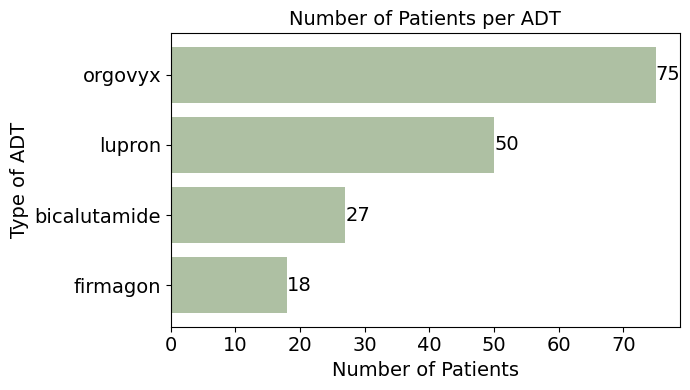

In [ ]:
# Standardize case of adt_agent
df['adt_agent'] = df['adt_agent'].str.lower()

# Count unique patients per NHT
num_patients = df.groupby('adt_agent')['unique_patient_id'].nunique()

# There are some misspellings and some patients who were on multiple drugs. Omit them for now.
num_patients = num_patients[num_patients > 3]
num_patients = num_patients.sort_values(ascending=True)


fig, ax = plt.subplots(figsize=(7,4))

ax.barh(num_patients.index, num_patients.values)
p=ax.barh(num_patients.index, num_patients.values, color='#aec0a3')
ax.bar_label(p, label_type='edge', fontsize=14)
ax.set_ylabel('Type of ADT', fontsize=14)
ax.set_xlabel('Number of Patients', fontsize=14)
ax.set_title('Number of Patients per ADT', fontsize=14)
ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

# Additional ideas: show percentages

# Combinations of NHT and ADT

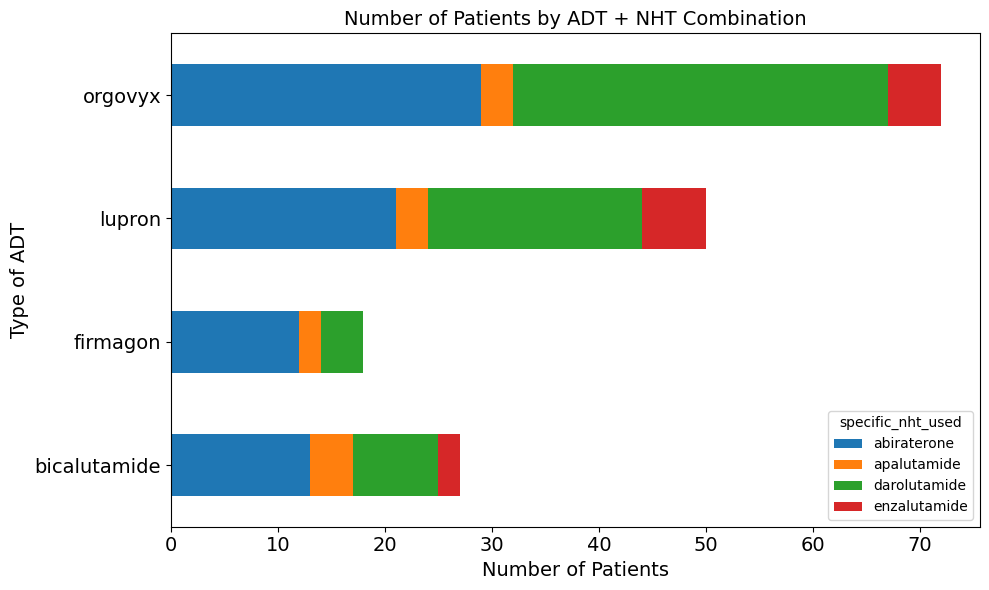

In [ ]:
combo_counts = (
    df.groupby(['adt_agent', 'specific_nht_used'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

combo_counts = combo_counts.loc[:, combo_counts.sum(axis=0) > 3]
combo_counts = combo_counts[combo_counts.sum(axis=1) > 5]

fig, ax = plt.subplots(figsize=(10,6))

combo_counts.plot(
    kind='barh',
    stacked=True,
    ax=ax
)

ax.set_ylabel('Type of ADT', fontsize=14)
ax.set_xlabel('Number of Patients', fontsize=14)
ax.set_title('Number of Patients by ADT + NHT Combination', fontsize=14)

ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

# Distribution of toxicities

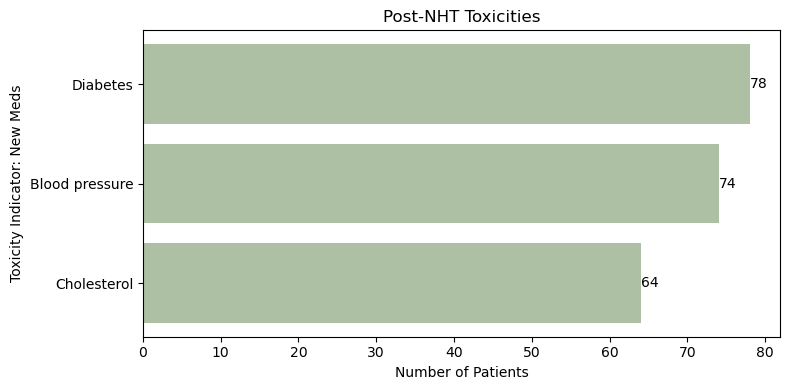

In [5]:
counts = {
    'bp_meds_post': (df['bp_meds_post'] != 0).sum(),
    'lipid_meds_post': (df['lipid_meds_post'] !=0).sum(),
    'dm_meds_post': (df['dm_meds_post'] != 0).sum(),
}

counts = dict(sorted(counts.items(), key=lambda item: item[1]))

#labels = list(counts.keys())
labels = ["Cholesterol", "Blood pressure", "Diabetes"]
values = list(counts.values())

fig, ax = plt.subplots(figsize=(8,4))
bars = ax.barh(labels, values, color='#aec0a3')

ax.bar_label(bars)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Toxicity Indicator: New Meds')
ax.set_title('Post-NHT Toxicities')
plt.tight_layout()
plt.show()

# Cardiovascular toxicities by NHT

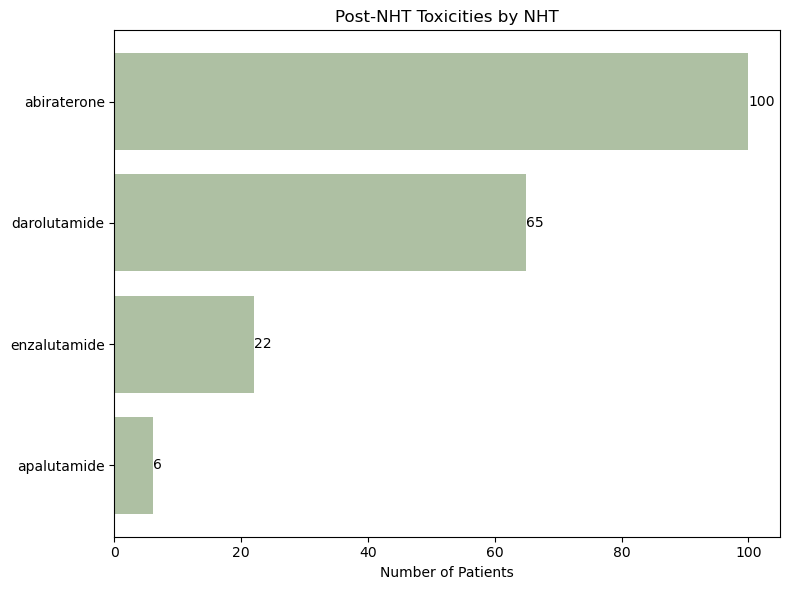

In [202]:
df['specific_nht_used'] = df['specific_nht_used'].str.lower()
df = df.dropna(subset=['specific_nht_used'])

nht_list = df['specific_nht_used'].unique()

nht_counts = dict.fromkeys(nht_list, 0)

for nht in nht_counts.keys():
    nht_counts[nht] += (df[df['specific_nht_used']==nht]['bp_meds_post'] != 0).sum()
    nht_counts[nht] += (df[df['specific_nht_used']==nht]['lipid_meds_post'] !=0).sum()
    nht_counts[nht] += (df[df['specific_nht_used']==nht]['dm_meds_post'] != 0).sum()

# There are some spelling errors. Omit them for now.
nht_counts = {k: v for k, v in nht_counts.items() if v >= 3}
nht_counts = dict(sorted(nht_counts.items(), key=lambda item: item[1]))

labels = list(nht_counts.keys())
values = list(nht_counts.values())

fig, ax = plt.subplots(figsize=(8,6))

bars = ax.barh(labels, values, color='#aec0a3')

ax.bar_label(bars)

ax.set_xlabel('Number of Patients')
ax.set_title('Post-NHT Toxicities by NHT')
plt.tight_layout()
plt.show()

# Cardiovascular Toxicities by ADT

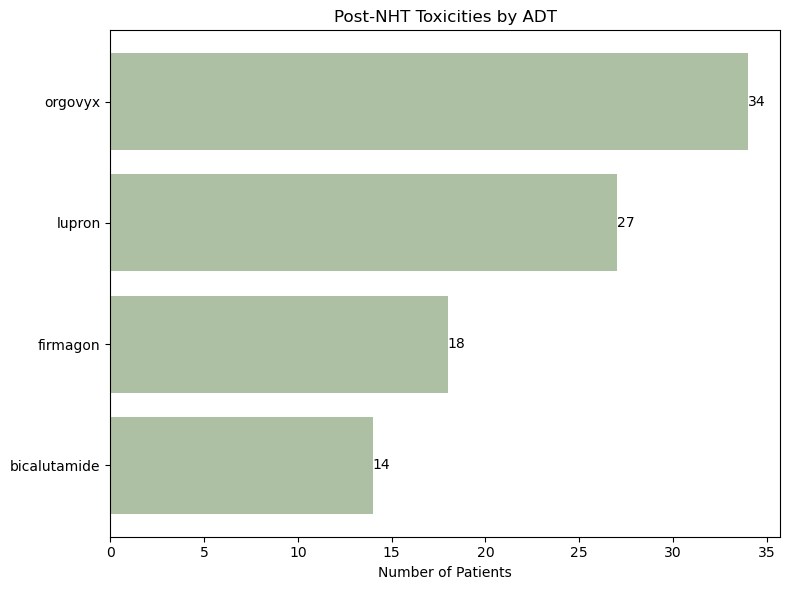

In [135]:
df['adt_agent'] = df['adt_agent'].str.lower()
df = df.dropna(subset=['adt_agent'])

adt_list = df['adt_agent'].unique()

adt_counts = dict.fromkeys(adt_list, 0)

for adt in adt_counts.keys():
    adt_counts[adt] += (df[df['adt_agent']==adt]['bp_meds_post'] != 0).sum()
    adt_counts[adt] += (df[df['adt_agent']==adt]['lipid_meds_post'] !=0).sum()
    adt_counts[adt] += (df[df['adt_agent']==adt]['dm_meds_post'] != 0).sum()
    #adt_counts[adt] += (df[df['adt_agent']==adt]['cards_post'] == 1).sum()
    #adt_counts[adt] += (df[df['adt_agent']==adt]['cards_referral'] == 1).sum()
    #adt_counts[adt] += (df[df['adt_agent']==adt]['echo_ordered'] == 1).sum()

# There are some spelling errors. Omit them for now. Also omit multiple ADTs.
adt_counts = {k: v for k, v in adt_counts.items() if v > 4}
adt_counts = dict(sorted(adt_counts.items(), key=lambda item: item[1]))

labels = list(adt_counts.keys())
values = list(adt_counts.values())

fig, ax = plt.subplots(figsize=(8,6))

bars = ax.barh(labels, values, color='#aec0a3')

ax.bar_label(bars)

ax.set_xlabel('Number of Patients')
ax.set_title('Post-NHT Toxicities by ADT')
plt.tight_layout()
plt.show()

# Toxicities by NHT

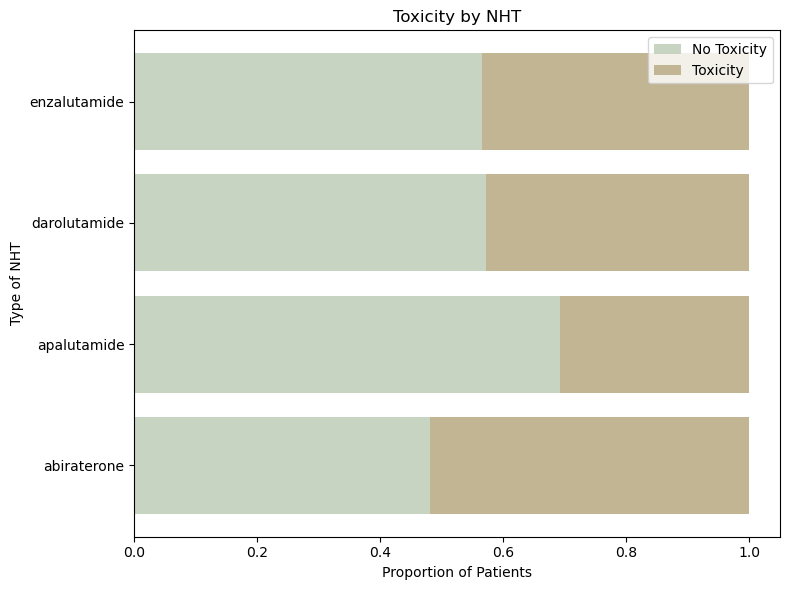

In [203]:
toxicity_cols = [
    'bp_meds_post', 'lipid_meds_post', 'dm_meds_post',
    'cards_post', 'cards_referral', 'echo_ordered', 'ecg_done'
]

df['specific_nht_used'] = df['specific_nht_used'].str.lower()

# patient has toxicity if ANY condition is met
df['toxicity'] = (
    (df['bp_meds_post'] != 0) |
    (df['lipid_meds_post'] != 0) |
    (df['dm_meds_post'] != 0)
    #|(df['cards_post'] == 1) |
    #(df['cards_referral'] == 1) |
    #(df['echo_ordered'] == 1)
)

counts = (
    df.groupby(['specific_nht_used', 'toxicity'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts[counts.sum(axis=1) >= 5]

fig, ax = plt.subplots(figsize=(8,6))
props = counts.div(counts.sum(axis=1), axis=0)
ax.barh(props.index, props[False], label='No Toxicity', color='#c7d4c1')
ax.barh(props.index, props[True], left=props[False], color='#c2b594', label='Toxicity')

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Toxicity by NHT')
ax.legend()

plt.tight_layout()
plt.show()

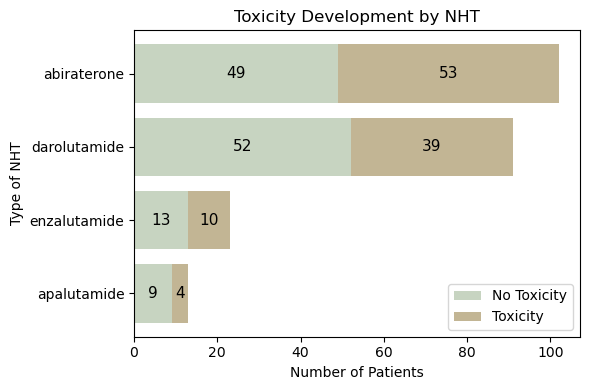

In [ ]:

# Standardize NHT names
df['specific_nht_used'] = df['specific_nht_used'].str.lower()

# Define toxicity indicator
df['toxicity'] = (
    (df['bp_meds_post'] != 0) |
    (df['lipid_meds_post'] != 0) |
    (df['dm_meds_post'] != 0)
)

# Count unique patients by NHT and toxicity
counts = (
    df.groupby(['specific_nht_used', 'toxicity'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

counts = counts[counts.sum(axis=1) >= 2]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[False], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[True], left=counts[False], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, label_type='center', fontsize=11)
ax.bar_label(bars_yes, label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Toxicity Development by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Toxicity by ADT

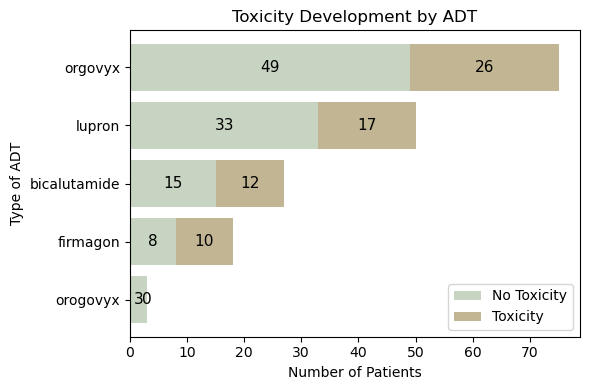

In [229]:

df['adt_agent'] = df['adt_agent'].str.lower()

# Define toxicity indicator
df['toxicity'] = (
    (df['bp_meds_post'] != 0) |
    (df['lipid_meds_post'] != 0) |
    (df['dm_meds_post'] != 0)
)

# Count unique patients by ADT and toxicity
counts = (
    df.groupby(['adt_agent', 'toxicity'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Remove ADTs with <3 patients
counts = counts[counts.sum(axis=1) >= 3]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[False], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[True], left=counts[False], color='#c2b594', label='Toxicity')
ax.bar_label(bars_no, label_type='center', fontsize=11)
ax.bar_label(bars_yes, label_type='center', fontsize=11)
ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of ADT')
ax.set_title('Toxicity Development by ADT')
ax.legend()

plt.tight_layout()
plt.show()

# Toxicities by health history

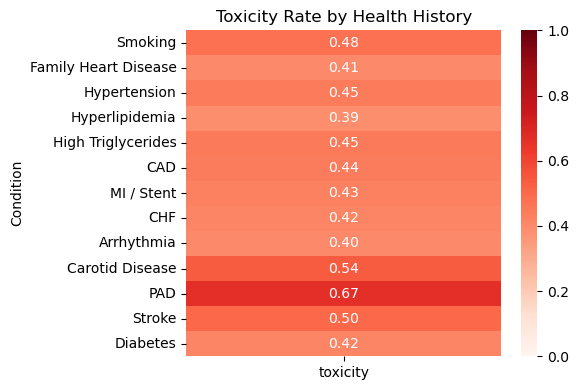

In [238]:
heatmap_data = []

health_cols = ["hx_smoking", "family_hx_hd", 'hx_htn', 'hx_hld', 'hx_high_tg', 'hx_cad', 'hx_mi_stent', 'hx_chf', 'hx_arrhythmia', 'hx_carotid', 'hx_pad', 'hx_cva', 'hx_dm2']

#affected if hx_smoking = 1 or 2, family_hx_hd = 1, hx_htn=1, hx_hld=1, hx_high_tg=1, hx_cad =1, hx_mi_stent=1, hx_chf=1, hx_arrhythmia=1, hx_carotid=1, hx_pad=1, hx_cva=1, hx_dm2=1

condition_filter = {
    "hx_smoking": lambda x: x >= 1,
    "family_hx_hd": lambda x: x == 1,
    'hx_htn': lambda x: x == 1,
    'hx_hld': lambda x: x == 1,
    'hx_high_tg': lambda x: x == 1,
    'hx_cad': lambda x: x == 1,
    'hx_mi_stent': lambda x: x == 1,
    'hx_chf': lambda x: x == 1,
    'hx_arrhythmia': lambda x: x == 1,
    'hx_carotid': lambda x: x == 1,
    'hx_pad': lambda x: x == 1,
    'hx_cva': lambda x: x == 1,
    'hx_dm2': lambda x: x == 1
}

condition_names = {
    "hx_smoking": "Smoking",
    "family_hx_hd": "Family Heart Disease",
    "hx_htn": "Hypertension",
    "hx_hld": "Hyperlipidemia",
    "hx_high_tg": "High Triglycerides",
    "hx_cad": "CAD",
    "hx_mi_stent": "MI / Stent",
    "hx_chf": "CHF",
    "hx_arrhythmia": "Arrhythmia",
    "hx_carotid": "Carotid Disease",
    "hx_pad": "PAD",
    "hx_cva": "Stroke",
    "hx_dm2": "Diabetes"
}

for col in health_cols:
    subset = df[condition_filter[col](df[col])]
    
    tox_value = subset['toxicity'].mean()
     
    heatmap_data.append({
        "condition": col,
        "toxicity": tox_value
    })

heatmap_df = pd.DataFrame(heatmap_data).set_index("condition")
heatmap_df.index = heatmap_df.index.map(condition_names)

plt.figure(figsize=(6,4))

ax=sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=1,
    fmt=".2f"
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.title("Toxicity Rate by Health History")
plt.xlabel("")
plt.ylabel("Condition")

plt.tight_layout()
plt.show()

# Toxicity rate by NHT+ADT combo

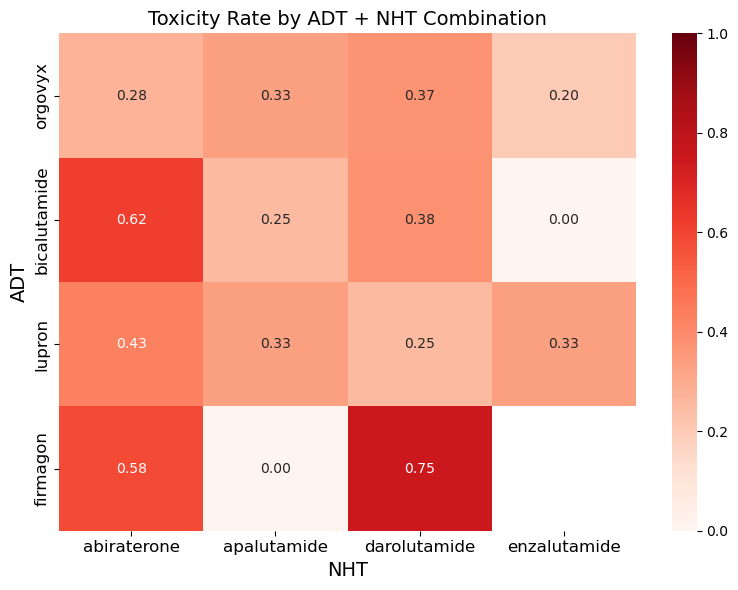

In [233]:
df['adt_agent'] = df['adt_agent'].str.lower()
df['specific_nht_used'] = df['specific_nht_used'].str.lower()

df['toxicity'] = (
    (df['bp_meds_post'] != 0) |
    (df['lipid_meds_post'] != 0) |
    (df['dm_meds_post'] != 0)
)

# Create toxicity indicator (True/False)
df['tox_event'] = df['toxicity'] > 0

# Count total patients per ADT+NHT
total_counts = (
    df.groupby(['adt_agent', 'specific_nht_used'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

# Count patients with toxicity
tox_counts = (
    df[df['tox_event']]
    .groupby(['adt_agent', 'specific_nht_used'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

# Align tables
tox_counts = tox_counts.reindex_like(total_counts).fillna(0)

# Compute toxicity rate
tox_rate = tox_counts / total_counts

# Remove rare NHTs (<4 patients total)
tox_rate = tox_rate.loc[:, total_counts.sum(axis=0) > 3]

# Remove rare ADTs (<4 patients total)
tox_rate = tox_rate.loc[total_counts.sum(axis=1) > 3]

# Sort ADTs by overall toxicity
tox_rate = tox_rate.loc[tox_rate.mean(axis=1).sort_values().index]

# Plot heatmap
plt.figure(figsize=(8,6))

ax = sns.heatmap(
    tox_rate,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    vmin=0,
    vmax=1
)

ax.set_xlabel("NHT", fontsize=14)
ax.set_ylabel("ADT", fontsize=14)
ax.set_title("Toxicity Rate by ADT + NHT Combination", fontsize=14)

ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()